In [1]:
from aeon.benchmarking.published_results import (
    load_classification_bake_off_2023_results,
)
from aeon.visualisation import plot_critical_difference
import polars as pl
import numpy as np
from aeon.datasets.tsc_datasets import univariate
from autotsc import utils
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tempfile
import boto3
import polars as pl
from tqdm import tqdm
from urllib.parse import urlparse
from concurrent.futures import ThreadPoolExecutor, as_completed

In [2]:
directory = "figures"
Path(directory).mkdir(parents=True, exist_ok=True)

In [3]:
def load_s3_parquet_cached(
    s3_prefix: str = "s3://tsc-glue/performance-benchmarking/",
    max_workers: int = 16,
) -> pl.DataFrame:

    cache_dir = os.path.join(tempfile.gettempdir(), "tsc-glue-cache")
    os.makedirs(cache_dir, exist_ok=True)

    parsed = urlparse(s3_prefix)
    bucket = parsed.netloc
    prefix = parsed.path.lstrip("/")

    s3 = boto3.client("s3")

    local_files = {
        f for f in os.listdir(cache_dir) if f.endswith(".parquet")
    }

    paginator = s3.get_paginator("list_objects_v2")
    remote_keys = []

    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if key.endswith(".parquet"):
                fname = key.rsplit("/", 1)[-1]
                if fname not in local_files:
                    remote_keys.append(key)

    def _download(key):
        fname = key.rsplit("/", 1)[-1]
        s3.download_file(
            bucket,
            key,
            os.path.join(cache_dir, fname),
        )

    if remote_keys:
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = [ex.submit(_download, k) for k in remote_keys]
            for _ in tqdm(as_completed(futures), total=len(futures)):
                pass

    local_paths = sorted(
        os.path.join(cache_dir, f)
        for f in os.listdir(cache_dir)
        if f.endswith(".parquet")
    )

    return pl.read_parquet(local_paths)

res_mine = load_s3_parquet_cached()
res_mine

dataset,model,fold,test_accuracy
str,str,i64,f64
"""BirdChicken""","""loky-stacker-v7-soft-rf""",0,0.9
"""SwedishLeaf""","""mr-hydra-contained-auto""",9,0.9776
"""BeetleFly""","""mr-hydra-kbest-5000""",15,0.95
"""Fish""","""mycatch22v2""",21,0.754286
"""StarLightCurves""","""mycatch22""",6,0.966367
…,…,…,…
"""NonInvasiveFetalECGThorax2""","""loky-stacker-v8-base""",4,0.969466
"""Symbols""","""mydummy""",25,0.173869
"""NonInvasiveFetalECGThorax1""","""loky-stacker-v7-soft-et""",27,0.970992


In [4]:
res_mine = res_mine.filter(
    (pl.col("model").str.contains("loky-stacker-v5"))==False
)

In [5]:
results_arr, datasets, classifiers = load_classification_bake_off_2023_results(
    num_resamples=30, as_array=True
)
results_arr.shape

(112, 34)

In [6]:
v = res_mine.filter(pl.col('fold')==5).pivot(values="test_accuracy", index="dataset", on="model").select(['dataset', 'loky-stacker-v7', 'loky-stacker-v6'])
v.with_columns((pl.col('loky-stacker-v7') - pl.col('loky-stacker-v6')).alias('diff')).sort('diff', descending=True)

dataset,loky-stacker-v7,loky-stacker-v6,diff
str,f64,f64,f64
"""CinCECGTorso""",0.999275,0.999275,0.0
"""Crop""",0.789107,0.789107,0.0
"""PowerCons""",1.0,1.0,0.0
"""Phoneme""",0.378692,0.378692,0.0
"""SmallKitchenAppliances""",0.853333,0.853333,0.0
…,…,…,…
"""CricketZ""",0.858974,0.858974,0.0
"""Symbols""",0.977889,0.977889,0.0
"""GunPoint""",0.993333,0.993333,0.0


In [7]:
pivoted = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='len')
numeric_cols = [c for c in pivoted.columns if c != "dataset"]
sum_row = pl.DataFrame([{"dataset": "all", **{c: pivoted[c].sum() for c in numeric_cols}}]).with_columns([
    pl.col(c).cast(pl.UInt32) for c in numeric_cols
])
result = pl.concat([pivoted, sum_row])
result

dataset,loky-stacker-v7-soft-rf,mr-hydra-contained-auto,mr-hydra-kbest-5000,mycatch22v2,mycatch22,loky-stacker-v6-soft-ridge,loky-stacker-v6,mr-hydra-kbest-auto,loky-stacker-v6-soft-et,mymrhydrav2,loky-stacker-v8-base,mydummy,loky-stacker-v7,mr-hydra-kbest-10000,loky-stacker-v6-soft-rf,loky-stacker-v7-soft-filter-ridge,loky-stacker-v7-soft-et,mr-hydra-kbest-30000,loky-stacker-v7-soft-ridge,mymrhydra
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""BirdChicken""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30
"""SwedishLeaf""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30
"""BeetleFly""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30
"""Fish""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30
"""StarLightCurves""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GunPointOldVersusYoung""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30
"""EOGHorizontalSignal""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30
"""OliveOil""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30


In [8]:
mine_classifiers = res_mine['model'].unique().to_list()

In [9]:
df_performance = pl.DataFrame(results_arr, schema=classifiers).with_columns(pl.Series("dataset", datasets))
df_performance_mine = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='mean')
df_performance_full = df_performance.join(other=df_performance_mine, on='dataset')

In [10]:
df_performance_full = df_performance_full#.drop(mine_classifiers)
len(df_performance_full)

112

In [11]:
df_performance_full = df_performance_full.drop([col for col in df_performance_full.columns if df_performance_full[col].null_count() > 0])

In [12]:
drop_models = ['ShapeDTW', 'EE', 'ResNet', 'CNN', 
               'CIF', 'BOSS', 'TSFresh', 'Arsenal', 
               'HC1', 'Hydra', '1NN-DTW', 'ROCKET', 
               'Mini-R', 'WEASEL-D', 'InceptionT', 'Signatures', 'RISE', 'DrCIF', 'TDE', 
               #'loky-stacker-v5-soft-et',
               #'loky-stacker-v5-soft-ridge',	
               #'loky-stacker-v5-soft-rf',	
               #'loky-stacker-v5-r1',
]

In [13]:
df_performance_full = df_performance_full.drop(drop_models)

In [14]:
df_performance_full.columns

['Catch22',
 'FreshPRINCE',
 'HC2',
 'Hydra-MR',
 'MrSQM',
 'Multi-R',
 'PF',
 'RDST',
 'RSF',
 'RSTSF',
 'STC',
 'TS-CHIEF',
 'TSF',
 'WEASEL',
 'cBOSS',
 'dataset',
 'loky-stacker-v7-soft-rf',
 'mr-hydra-contained-auto',
 'mr-hydra-kbest-5000',
 'mycatch22v2',
 'mycatch22',
 'loky-stacker-v6-soft-ridge',
 'loky-stacker-v6',
 'mr-hydra-kbest-auto',
 'loky-stacker-v6-soft-et',
 'mymrhydrav2',
 'loky-stacker-v8-base',
 'mydummy',
 'loky-stacker-v7',
 'mr-hydra-kbest-10000',
 'loky-stacker-v6-soft-rf',
 'loky-stacker-v7-soft-filter-ridge',
 'loky-stacker-v7-soft-et',
 'mr-hydra-kbest-30000',
 'loky-stacker-v7-soft-ridge',
 'mymrhydra']

/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/aeon/visualisation/results/_critical_difference.py:217: UserWarning: Estimators mr-hydra-contained-auto and mr-hydra-kbest-auto have the same performanceon all datasets. This may cause problems when forming cliques.
  p_values = wilcoxon_test(ordered_scores, ordered_labels, lower_better)


(<Figure size 600x540 with 1 Axes>, <Axes: >)

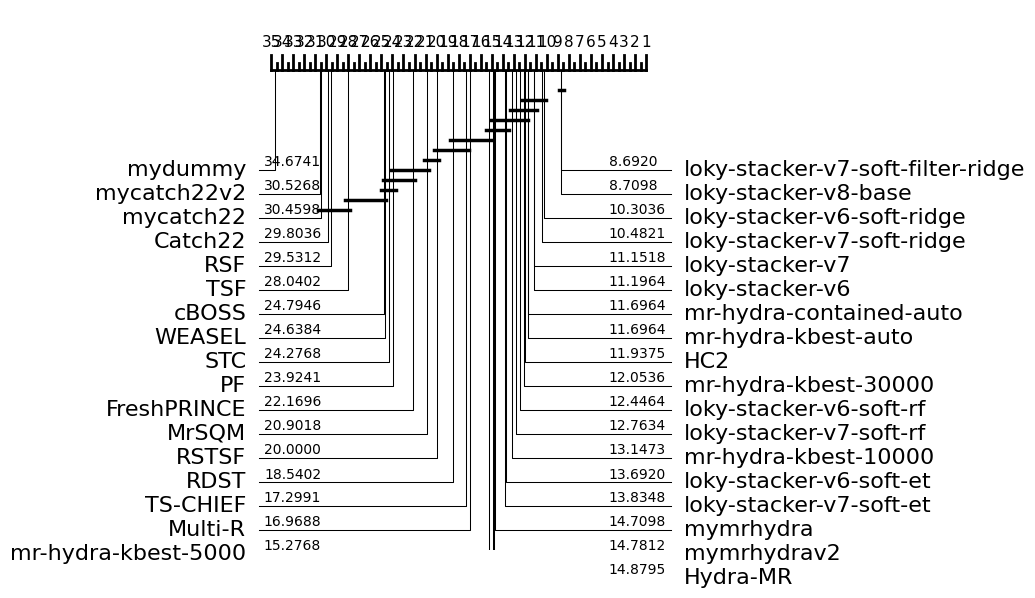

In [15]:
clsf = df_performance_full.select([c for c in df_performance_full.columns if c != "dataset"])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

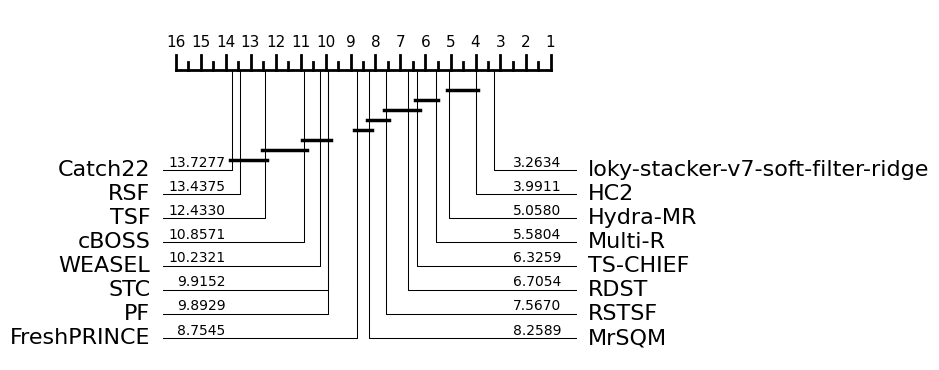

In [16]:
clsf = df_performance_full.select([
    c for c in df_performance_full.columns if c != "dataset" and (c in classifiers or c == 'loky-stacker-v7-soft-filter-ridge')
])
plot_critical_difference(clsf.to_numpy(), clsf.columns)
plt.savefig(f"{directory}/critical_difference.pdf", bbox_inches='tight', pad_inches=0)


In [17]:
clsf

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,loky-stacker-v7-soft-filter-ridge
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.888333,0.923333,0.946667,0.91,0.958333,0.89,0.903333,0.913333,0.833333,0.963333,0.915,0.963333,0.821667,0.906667,0.981667,0.941667
0.881227,0.948427,0.962613,0.97248,0.956693,0.97296,0.953067,0.963467,0.882827,0.951573,0.930507,0.96192,0.893547,0.960053,0.915573,0.975627
0.851667,0.881667,0.911667,0.911667,0.963333,0.895,0.86,0.926667,0.875,0.885,0.951667,0.958333,0.823333,0.92,0.96,0.895
0.78,0.886286,0.984571,0.981524,0.983429,0.984571,0.933905,0.98419,0.854667,0.921333,0.941333,0.981524,0.824952,0.97581,0.966286,0.981143
0.969374,0.978813,0.981852,0.981318,0.979861,0.981423,0.979569,0.981034,0.962668,0.978703,0.977955,0.981128,0.969884,0.973519,0.97328,0.982022
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.960067,0.943116,0.97263,0.971792,0.970419,0.972563,0.967035,0.965662,0.94057,0.950955,0.911524,0.970821,0.884724,0.966667,0.952931,0.954238
1.0,1.0,0.999894,1.0,0.992063,1.0,1.0,1.0,1.0,1.0,0.990899,1.0,1.0,0.99164,0.999048,1.0
0.724862,0.768508,0.814917,0.871823,0.790516,0.866851,0.824401,0.779466,0.690516,0.75884,0.767127,0.853683,0.69291,0.688858,0.710313,0.881215


(<Figure size 600x260 with 1 Axes>, <Axes: >)

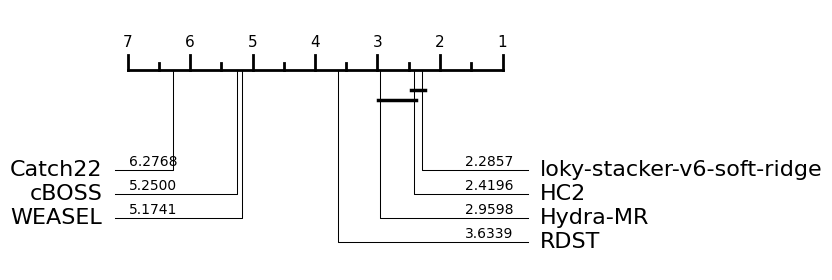

In [18]:
clsf = df_performance_full.select(['loky-stacker-v6-soft-ridge', 'HC2', 'Hydra-MR', 'cBOSS', 'Catch22', 'RDST', 'WEASEL'])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

(<Figure size 600x260 with 1 Axes>, <Axes: >)

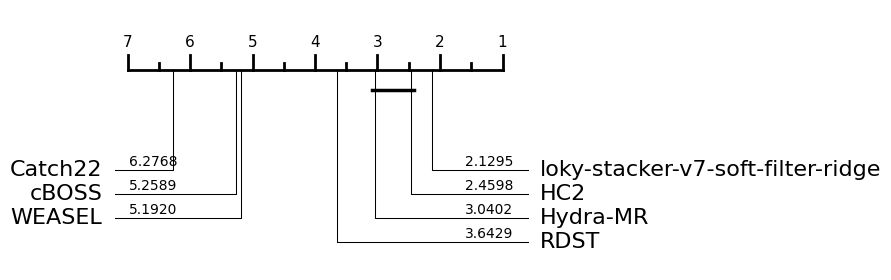

In [19]:
clsf = df_performance_full.select(['loky-stacker-v7-soft-filter-ridge', 'HC2', 'Hydra-MR', 'cBOSS', 'Catch22', 'RDST', 'WEASEL'])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

In [20]:
v = (df_performance_full['loky-stacker-v6-soft-ridge'] - df_performance_full['HC2']).to_numpy()
(v>0).sum(), (v<0).sum(), (v==0).sum()

(np.int64(61), np.int64(46), np.int64(5))

In [21]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

df_performance_full.join(stats, on='dataset').sort('n_train')

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,dataset,loky-stacker-v7-soft-rf,mr-hydra-contained-auto,mr-hydra-kbest-5000,mycatch22v2,mycatch22,loky-stacker-v6-soft-ridge,loky-stacker-v6,mr-hydra-kbest-auto,loky-stacker-v6-soft-et,mymrhydrav2,loky-stacker-v8-base,mydummy,loky-stacker-v7,mr-hydra-kbest-10000,loky-stacker-v6-soft-rf,loky-stacker-v7-soft-filter-ridge,loky-stacker-v7-soft-et,mr-hydra-kbest-30000,loky-stacker-v7-soft-ridge,mymrhydra,n_train,n_test,n_classes,series_length
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
0.908279,0.916993,0.946841,0.950436,0.890741,0.952179,0.956754,0.944989,0.919935,0.937146,0.924619,0.945861,0.940632,0.894553,0.881046,"""DiatomSizeReduction""",0.952179,0.949891,0.948366,0.90512,0.904248,0.952179,0.952179,0.949891,0.952179,0.952614,0.952179,0.300654,0.952179,0.951525,0.952179,0.952179,0.952179,0.954575,0.952179,0.952179,16,306,4,345
0.986613,0.999866,0.999331,0.984739,0.857028,0.996252,1.0,0.965194,1.0,1.0,0.905087,1.0,1.0,1.0,0.998527,"""InsectEPGSmallTrain""",0.999732,1.0,1.0,0.983668,0.985944,1.0,0.997189,1.0,1.0,0.996921,1.0,0.473896,0.997189,1.0,0.999732,1.0,1.0,0.999465,1.0,0.996921,17,249,3,601
0.851667,0.881667,0.911667,0.911667,0.963333,0.895,0.86,0.926667,0.875,0.885,0.951667,0.958333,0.823333,0.92,0.96,"""BeetleFly""",0.898333,0.928333,0.921667,0.853333,0.855,0.895,0.9,0.928333,0.89,0.905,0.895,0.5,0.9,0.926667,0.898333,0.895,0.89,0.918333,0.895,0.906667,20,20,2,512
0.888333,0.923333,0.946667,0.91,0.958333,0.89,0.903333,0.913333,0.833333,0.963333,0.915,0.963333,0.821667,0.906667,0.981667,"""BirdChicken""",0.941667,0.906667,0.908333,0.878333,0.883333,0.933333,0.923333,0.906667,0.948333,0.891667,0.938333,0.5,0.923333,0.908333,0.941667,0.941667,0.948333,0.905,0.933333,0.896667,20,20,2,512
0.892323,0.972789,0.970068,0.965792,0.95345,0.966569,0.948019,0.968416,0.883479,0.975607,0.955102,0.961836,0.954227,0.939456,0.942857,"""Chinatown""",0.971817,0.969485,0.970068,0.906414,0.904179,0.974733,0.970068,0.969485,0.972206,0.966667,0.975607,0.274052,0.969971,0.969388,0.971914,0.97551,0.972303,0.967055,0.974733,0.967055,20,343,2,24
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.792152,0.847708,0.843706,0.859402,0.816861,0.857964,0.829099,0.829099,0.817211,0.841414,0.833877,0.82533,0.811772,0.811305,0.780109,"""PhalangesOutlinesCorrect""",0.857459,0.855089,0.842424,0.787529,0.788112,0.862626,0.860917,0.855089,0.856721,0.856177,0.863015,0.613054,0.860878,0.847086,0.857304,0.86251,0.856527,0.854662,0.862665,0.855478,1800,858,2,80
0.908636,1.0,0.953712,0.955354,0.95,0.954141,0.850025,0.949242,0.876515,0.977803,0.934242,0.947399,0.81846,0.960657,0.908939,"""FordA""",0.985303,0.955884,0.956288,0.910076,0.908737,0.981288,0.983283,0.955884,0.985076,0.955278,0.981414,0.515909,0.983207,0.955707,0.985429,0.981414,0.984722,0.95548,0.98154,0.956162,3601,1320,2,500
0.867778,0.9207,0.933868,0.931193,0.922798,0.929671,0.839383,0.928601,0.85786,0.922593,0.9193,0.919465,0.785267,0.928354,0.883086,"""FordB""",0.936214,0.93107,0.929095,0.870782,0.870905,0.938601,0.93716,0.93107,0.93642,0.929588,0.9407,0.495062,0.937078,0.932922,0.936255,0.940741,0.936502,0.930905,0.938519,0.929424,3636,810,2,500


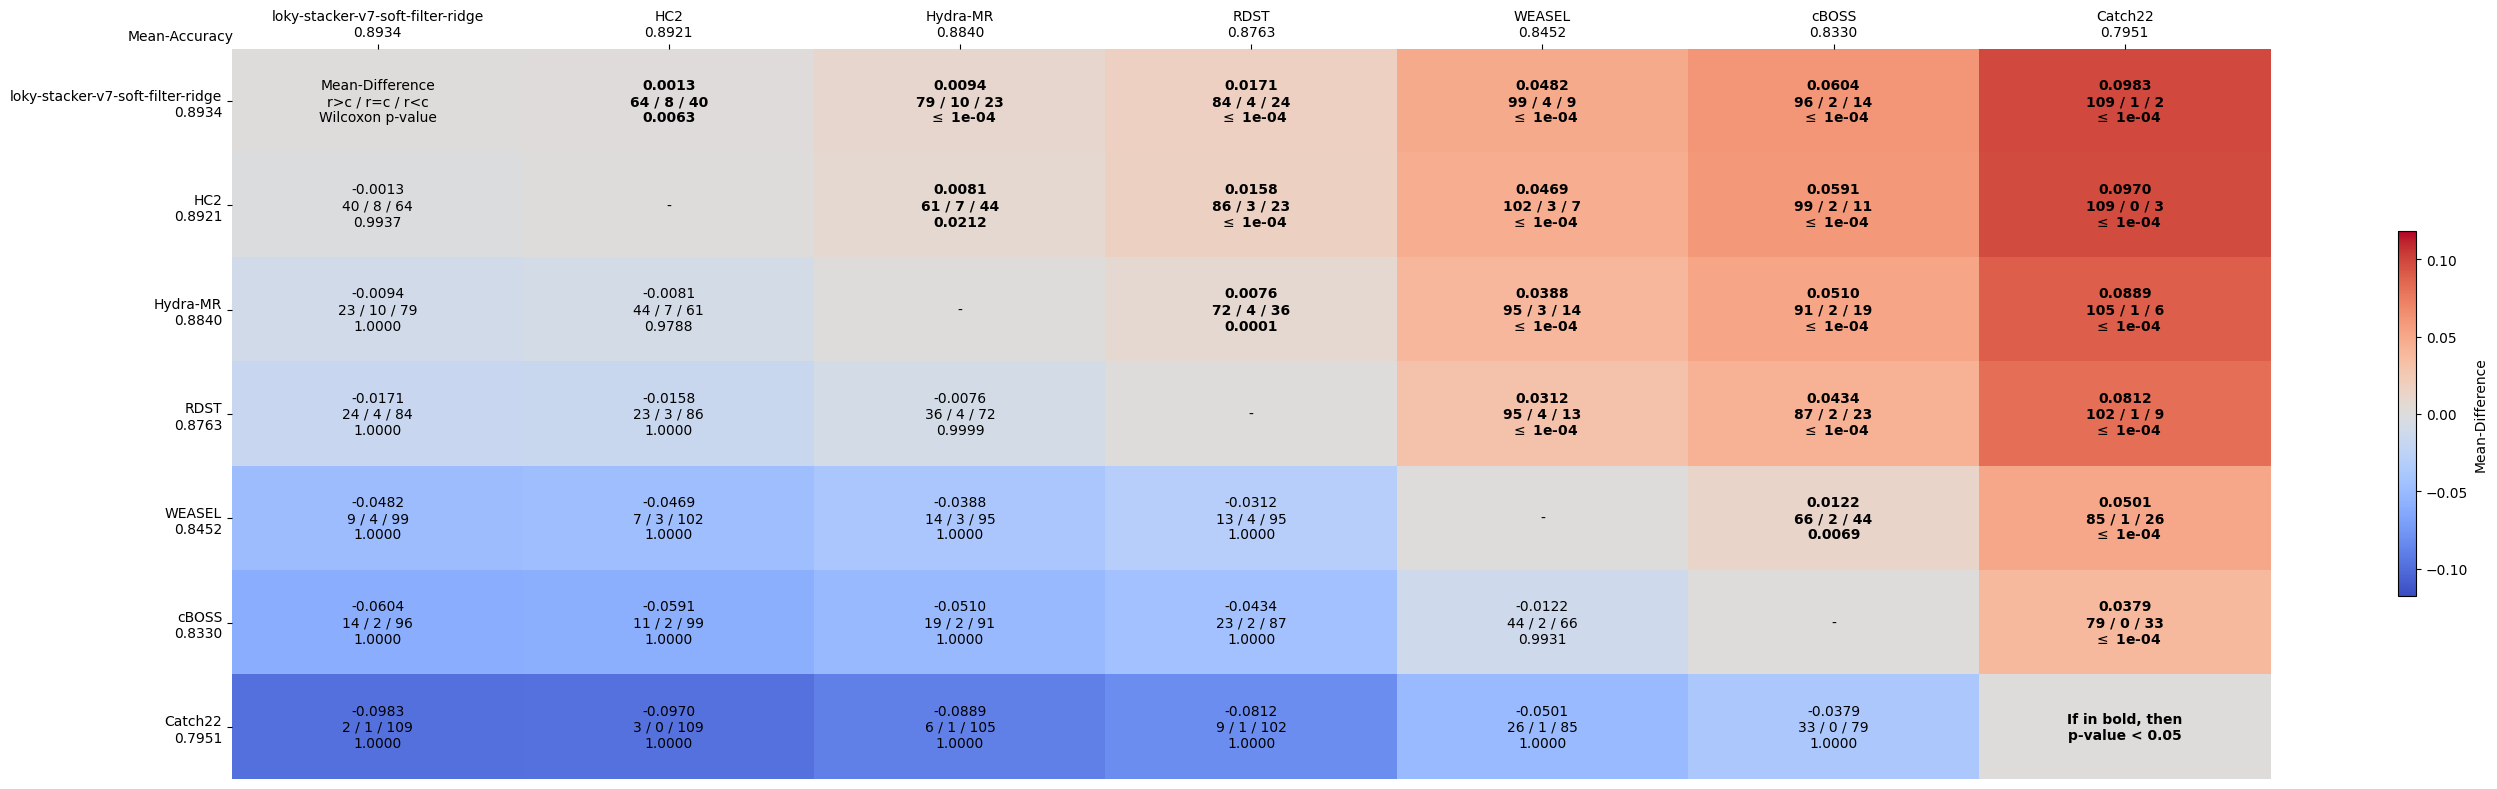

In [22]:
from aeon.visualisation import create_multi_comparison_matrix

create_multi_comparison_matrix(clsf.to_pandas())
plt.savefig(f"{directory}/multi_comparison_matrix.pdf", bbox_inches='tight', pad_inches=0)

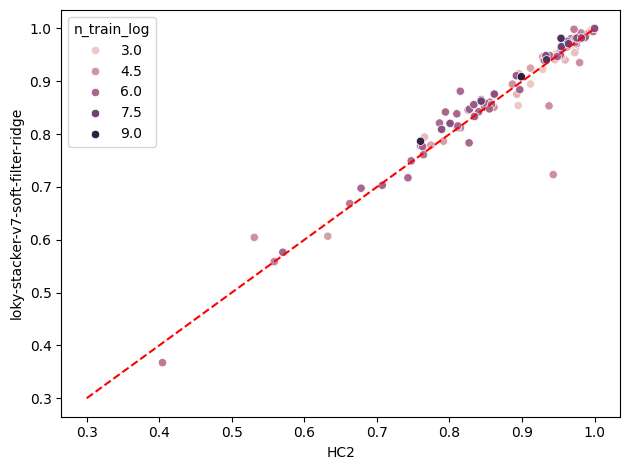

In [23]:
m1 = 'HC2'
m2 = 'loky-stacker-v7-soft-filter-ridge'
data = df_performance_full.join(stats, on='dataset').with_columns(pl.col('n_train').log().alias('n_train_log')).sort('n_train')
sns.scatterplot(data=data.to_pandas(), x=m1, y=m2, hue='n_train_log')
#plt.scatter(clsf[m1], clsf[m2], alpha=0.7, edgecolors='b', s=5)
plt.xlabel(m1)
plt.ylabel(m2)
plt.plot([0.3, 1], [0.3, 1], 'r--')

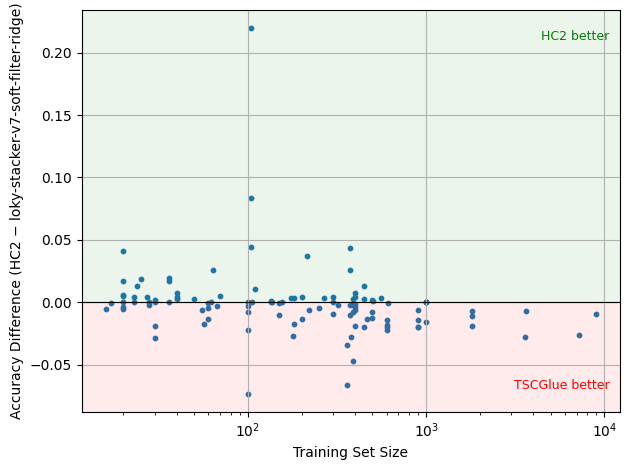

In [24]:
plt.scatter(data['n_train'], data[m1]-data[m2], s=10)
plt.xlabel('Training Set Size')
plt.ylabel(f'Accuracy Difference ({m1} − {m2})')
plt.xscale('log')
plt.grid()
plt.axhline(0, color='black', linewidth=0.8)
ylim = plt.gca().get_ylim()
plt.axhspan(0, ylim[1], alpha=0.08, color='green')
plt.axhspan(ylim[0], 0, alpha=0.08, color='red')
plt.text(0.98, 0.95, 'HC2 better', transform=plt.gca().transAxes, ha='right', va='top', fontsize=9, color='green')
plt.text(0.98, 0.05, 'TSCGlue better', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=9, color='red')
plt.ylim(ylim)

directory = "figures"
Path(directory).mkdir(parents=True, exist_ok=True)

plt.savefig(f"{directory}/train_size.pdf", bbox_inches='tight', pad_inches=0)

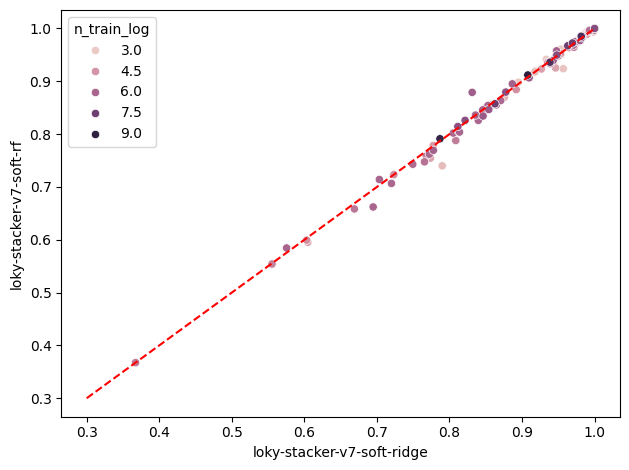

In [25]:
m1 = 'loky-stacker-v7-soft-ridge'
m2 = 'loky-stacker-v7-soft-rf'
data = df_performance_full.join(stats, on='dataset').with_columns(pl.col('n_train').log().alias('n_train_log')).sort('n_train')
sns.scatterplot(data=data.to_pandas(), x=m1, y=m2, hue='n_train_log')
#plt.scatter(clsf[m1], clsf[m2], alpha=0.7, edgecolors='b', s=5)
plt.xlabel(m1)
plt.ylabel(m2)
plt.plot([0.3, 1], [0.3, 1], 'r--')

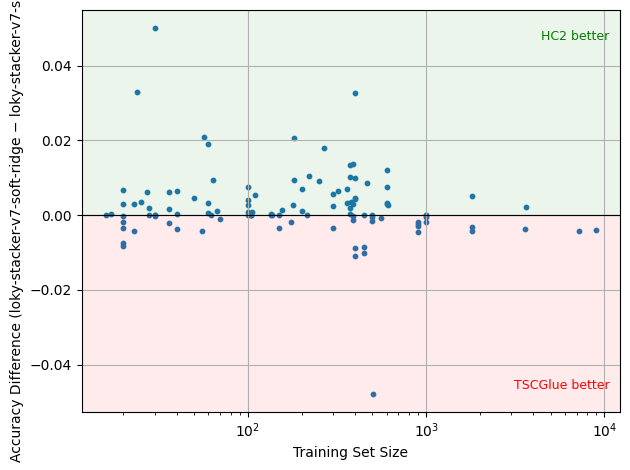

In [26]:
plt.scatter(data['n_train'], data[m1]-data[m2], s=10)
plt.xlabel('Training Set Size')
plt.ylabel(f'Accuracy Difference ({m1} − {m2})')
plt.xscale('log')
plt.grid()
plt.axhline(0, color='black', linewidth=0.8)
ylim = plt.gca().get_ylim()
plt.axhspan(0, ylim[1], alpha=0.08, color='green')
plt.axhspan(ylim[0], 0, alpha=0.08, color='red')
plt.text(0.98, 0.95, 'HC2 better', transform=plt.gca().transAxes, ha='right', va='top', fontsize=9, color='green')
plt.text(0.98, 0.05, 'TSCGlue better', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=9, color='red')
plt.ylim(ylim)

directory = "figures"
Path(directory).mkdir(parents=True, exist_ok=True)

plt.savefig(f"{directory}/train_size.pdf", bbox_inches='tight', pad_inches=0)